In [1]:
import h5py
import numpy as np
from utils.read_cy_profile import abundance_match_and_output_mean_cy
import os
from utils.read_data_flamingo import setup_flamingo_cosmology

from utils.add_noise2cy import(
    load_Nyy_cmbs4,
    load_Nyy_so,
    YProfileNoiseAdder,
    save_NOISEcomptony_profiles_hdf5,
)
# ---------- plotting defaults ----------
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors

from matplotlib.lines import Line2D
from scipy.special import j1

mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family'] = 'serif'

cosmo = setup_flamingo_cosmology()
h = cosmo.H0 / 100.0
# print(h)

################## Read in Compton-y profiles for individual halos measured from Flamingo simulation  ####################

proj_depth = 300 #300 comoving Mpc/h
data_path  = "/projects/lyang4/projection_effects/cluster_cosmology/Flamingo/L1000N3600/SZ/data/"
cy_file = f"Compton_y_20rpbins_rp0.1-30.0_projdepth{proj_depth}_m500c.1e13_hpz.hdf5"

with h5py.File(data_path + cy_file, "r") as all_dat:
    rp_ih_all      = all_dat['r_bins'][:]    # comoving Mpc/h, shape[ihalo, rps]: (83731, 20)
    cy_ih_all      = all_dat['cy_at_rp'][:]  # dimensionless, shape[ihalo, cy_at_rps]: (83731, 20)
    halo_mass_all  = all_dat['halo_mass'][:] # Msun/h, shape: 83731


################## choose which experiment NOISE curve to use  ####################

# ---------- CMB-S4 ----------
cmb_s4_loc = "/projects/lyang4/projection_effects/cluster_cosmology/CMB_maps/CMB-S4/"
ell_s4, Nyy_s4 = load_Nyy_cmbs4(
    cmb_s4_loc + "S4_190604d_2LAT_T_default_noisecurves_deproj0_SENS0_mask_16000_ell_TT_yy.txt"
)

# --------------------------------- SO ------------------------------------
### There are [Deproj-0] [Deproj-1] [Deproj-2] [Deproj-3] for SO noise ###
### Set deproj = 0/1/2/3 to select one 
### I use deproj = 0, which is the standard noise for SO for both goal and baseline
### I have also tested and compared 0/1

# ---------- SO baseline noise ----------
so_loc = "/projects/lyang4/projection_effects/cluster_cosmology/CMB_maps/SO/"
ell_so_bl_dp0, Nyy_so_bl_dp0 = load_Nyy_so(
    so_loc + "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt", deproj=0 
)
ell_so_bl_dp1, Nyy_so_bl_dp1 = load_Nyy_so(
    so_loc + "SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt", deproj=1
)

# ---------- SO goal noise ----------
ell_so_gl_dp0, Nyy_so_gl_dp0 = load_Nyy_so(
    so_loc + "SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_tSZ.txt", deproj=0
)
    
ell_so_gl_dp1, Nyy_so_gl_dp1 = load_Nyy_so(
    so_loc + "SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_tSZ.txt", deproj=1
)


# ---------- Check rp/theta bins ----------
rp_min, rp_max, n_bins = 0.1, 30.0, 20  # Mpc/h
rp_edges = np.logspace(np.log10(rp_min), np.log10(rp_max), n_bins+1)
# rp_mid_test = np.sqrt(rp_edges[1:]*rp_edges[:-1]) 
# print(rp_edges)
# print(rp_mid_test)
# rpmid_list = np.sqrt(R_comv_bins_inner[:-1] * R_comv_bins_inner[1:])[1:] #Unit: cMpc/h
# print(rp_ih_all[0,:])


# Just in case: comoving distance at z=0.3:
chi = cosmo.comovingDistance(0.0, 0.3)

theta_edges = rp_edges / chi  # radians

In [2]:
# ---- build "adder" once we have theta_edges ----
# Example for CMB-S4:
adder_s4 = YProfileNoiseAdder(
    theta_edges,
    ell_s4,
    Nyy_s4,
    seed=426789, ### fix to check
    ell_extend_mode="flat",
    ell_min_target=2,
    jitter_rel=1e-10,   # slightly larger is fine; it’s *tiny* vs diagonal scale
)

print("CMB-S4 jitter_used =", adder_s4.jitter_used)

### Add noise to all 83731 halos' cy.
cy_ih_s4noise = adder_s4.add_to_many(cy_ih_all)
print(60*"-")
###############################################################
# For SO baseline deproj-0:
adder_so_bl_dp0 = YProfileNoiseAdder(
    theta_edges,
    ell_so_bl_dp0,
    Nyy_so_bl_dp0,
    seed=426789,
    ell_extend_mode="flat",
    ell_min_target=2,
    jitter_rel=1e-10,   # slightly larger is fine; it’s *tiny* vs diagonal scale
)

print("SO baseline Deproj-0 jitter_used =", adder_so_bl_dp0.jitter_used)

cy_ih_so_blnoise_dp0 = adder_so_bl_dp0.add_to_many(cy_ih_all)

print(60*"-")

###############################################################
# For SO baseline deproj-1:
adder_so_bl_dp1 = YProfileNoiseAdder(
    theta_edges,
    ell_so_bl_dp1,
    Nyy_so_bl_dp1,
    seed=426789,
    ell_extend_mode="flat",
    ell_min_target=2,
    jitter_rel=1e-10,   
)

print("SO baseline Deproj-0 jitter_used =", adder_so_bl_dp1.jitter_used)

cy_ih_so_blnoise_dp1 = adder_so_bl_dp1.add_to_many(cy_ih_all)

print(60*"-")

###############################################################
# For SO goal deproj-0:
adder_so_gl_dp0 = YProfileNoiseAdder(
    theta_edges,
    ell_so_gl_dp0,
    Nyy_so_gl_dp0,
    seed=426789,
    ell_extend_mode="flat",
    ell_min_target=2,
    jitter_rel=1e-10,   
)

print("SO goal Deproj-0 jitter_used =", adder_so_gl_dp0.jitter_used)

cy_ih_so_glnoise_dp0 = adder_so_gl_dp0.add_to_many(cy_ih_all)


###############################################################
# For SO goal deproj-1:
adder_so_gl_dp1 = YProfileNoiseAdder(
    theta_edges,
    ell_so_gl_dp1,
    Nyy_so_gl_dp1,
    seed=426789,
    ell_extend_mode="flat",
    ell_min_target=2,
    jitter_rel=1e-10,   
)

print("SO goal Deproj-0 jitter_used =", adder_so_gl_dp1.jitter_used)

cy_ih_so_glnoise_dp1 = adder_so_gl_dp1.add_to_many(cy_ih_all)






CMB-S4 jitter_used = 1.6571703305555752e-22
------------------------------------------------------------
SO baseline Deproj-0 jitter_used = 3.4465749917421793e-22
------------------------------------------------------------
SO baseline Deproj-0 jitter_used = 8.001072456347239e-22
------------------------------------------------------------
SO goal Deproj-0 jitter_used = 2.9209905683836354e-22
SO goal Deproj-0 jitter_used = 6.509411725857143e-22


In [3]:
# # ---------------------------------------------------------------------------------------------
# save_dir = ""
# # ---------------------------------------------------------------------------------------------

# savepath = os.path.join(save_dir, "Compton_y_projdepth300cMpch_m500c_noise_s4_os_dp0.hdf5")

# meta = dict(
#     z=0.3,
#     proj_depth_cMpc_h=300,
#     mass_def="M500c",
#     cy_units="dimensionless",
#     s4_curve="S4_190604d_2LAT_T_default_noisecurves_deproj0_SENS0_mask_16000_ell_TT_yy.txt",
#     so_baseline_curve="SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt (Deproj-0)",
#     so_goal_curve="SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_tSZ.txt (Deproj-0)",
#     rp_units="comoving Mpc/h",
# )

# save_NOISEcomptony_profiles_hdf5(
#     savepath,
#     rp_centers=rp_ih_all,          # shape (20,) 
#     cy_s4=cy_ih_s4noise,
#     cy_so_baseline=cy_ih_so_blnoise_dp0,
#     cy_so_goal=cy_ih_so_glnoise_dp0,
#     halo_mass=halo_mass_all,
#     meta=meta,
#     overwrite=True,
# )


In [4]:
# savepath = os.path.join(save_dir, "Compton_y_projdepth300cMpch_m500c_noise_s4_os_dp1.hdf5")

# meta = dict(
#     z=0.3,
#     proj_depth_cMpc_h=300,
#     mass_def="M500c",
#     cy_units="dimensionless",
#     s4_curve="S4_190604d_2LAT_T_default_noisecurves_deproj0_SENS0_mask_16000_ell_TT_yy.txt",
#     so_baseline_curve="SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt (Deproj-1)",
#     so_goal_curve="SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_tSZ.txt (Deproj-1)",
#     rp_units="comoving Mpc/h",
# )

# save_NOISEcomptony_profiles_hdf5(
#     savepath,
#     rp_centers=rp_ih_all,          # shape (20,) 
#     cy_s4=cy_ih_s4noise,
#     cy_so_baseline=cy_ih_so_blnoise_dp1,
#     cy_so_goal=cy_ih_so_glnoise_dp1,
#     halo_mass=halo_mass_all,
#     meta=meta,
#     overwrite=True,
# )


In [5]:
# ## Quick check the HDF5 file

# cy_path = os.path.join(save_dir, "Compton_y_projdepth300cMpch_m500c_noise_s4_os_dp0.hdf5")

# fname = cy_path
# with h5py.File(fname, "r") as f:
#     print("Keys:", list(f.keys()))
#     print("Attrs:", list(f.attrs.keys()))


In [6]:
# ## Read arrays out 
# with h5py.File(fname, "r") as f:
#     cy_s4 = f["cy_s4_noise"][:]                 # (Nhalo, Nrp)
#     cy_so_bl = f["cy_so_baseline_noise"][:]     # (Nhalo, Nrp)
#     cy_so_goal = f["cy_so_goal_noise"][:]       # (Nhalo, Nrp)
#     mhalo = f["halo_mass_msun_h"][:]            # (Nhalo,)

#     # radii: depending on what saved
#     rp_centers = f["rp_centers_comv_mpc_h"][:] if "rp_centers_comv_mpc_h" in f else None
#     rp_per_halo = f["rp_comv_mpc_h"][:] if "rp_comv_mpc_h" in f else None


In [7]:
# ## Read metadata attributes (z, proj depth, filenames, etc.)
# with h5py.File(fname, "r") as f:
#     meta = dict(f.attrs)
# print(meta.get("z"), meta.get("proj_depth_cMpc_h"))
# # 0.3 300

In [8]:
# Just check that the noise matrix makes sense
def jitter_report(adder, name=""):
    C = adder.C
    j = adder.jitter_used
    dmean = float(np.mean(np.diag(C)))
    dmax  = float(np.max(np.diag(C)))
    ratio_mean = j / dmean if dmean > 0 else np.nan
    ratio_max  = j / dmax  if dmax  > 0 else np.nan

    # check eigenvalue floor (optional)
    wmin = float(np.min(np.linalg.eigvalsh(0.5*(C+C.T))))
    print(f"{name}")
    print(f"  jitter_used   = {j:.3e}")
    print(f"  mean(diag C)  = {dmean:.3e}  -> jitter/mean(diag) = {ratio_mean:.3e}")
    print(f"  max(diag C)   = {dmax:.3e}  -> jitter/max(diag)  = {ratio_max:.3e}")
    print(f"  min eigen(C)  = {wmin:.3e}")
    print()

jitter_report(adder_s4, "CMB-S4")
jitter_report(adder_so_bl_dp0, "SO Deproj-0")
jitter_report(adder_so_gl_dp0, "SO Deproj-1")

sig0 = np.sqrt(np.diag(adder_so_bl_dp0.C))
sig1 = np.sqrt(np.diag(adder_so_gl_dp0.C))
print("median(sig1/sig0) =", np.median(sig1/sig0))
print("range(sig1/sig0)  =", np.min(sig1/sig0), np.max(sig1/sig0))

### Check the matrix for baseline deproj=0
Ceff = adder_so_bl_dp0.C + adder_so_bl_dp0.jitter_used*np.eye(adder_so_bl_dp0.C.shape[0])
wmin_eff = np.min(np.linalg.eigvalsh(0.5*(Ceff + Ceff.T)))
print("min eigen(C_eff) =", wmin_eff)


### Check the matrix for goal deproj=0
Ceff = adder_so_gl_dp0.C + adder_so_gl_dp0.jitter_used*np.eye(adder_so_gl_dp0.C.shape[0])
wmin_eff = np.min(np.linalg.eigvalsh(0.5*(Ceff + Ceff.T)))
print("min eigen(C_eff) =", wmin_eff)


CMB-S4
  jitter_used   = 1.657e-22
  mean(diag C)  = 1.657e-12  -> jitter/mean(diag) = 1.000e-10
  max(diag C)   = 4.968e-12  -> jitter/max(diag)  = 3.335e-11
  min eigen(C)  = 8.618e-28

SO Deproj-0
  jitter_used   = 3.447e-22
  mean(diag C)  = 3.447e-12  -> jitter/mean(diag) = 1.000e-10
  max(diag C)   = 1.341e-11  -> jitter/max(diag)  = 2.571e-11
  min eigen(C)  = 1.242e-27

SO Deproj-1
  jitter_used   = 2.921e-22
  mean(diag C)  = 2.921e-12  -> jitter/mean(diag) = 1.000e-10
  max(diag C)   = 1.023e-11  -> jitter/max(diag)  = 2.856e-11
  min eigen(C)  = 2.857e-27

median(sig1/sig0) = 0.9620755433196809
range(sig1/sig0)  = 0.8734762942348988 0.9936411545959161
min eigen(C_eff) = 3.4465495648280333e-22
min eigen(C_eff) = 2.9210300080398348e-22


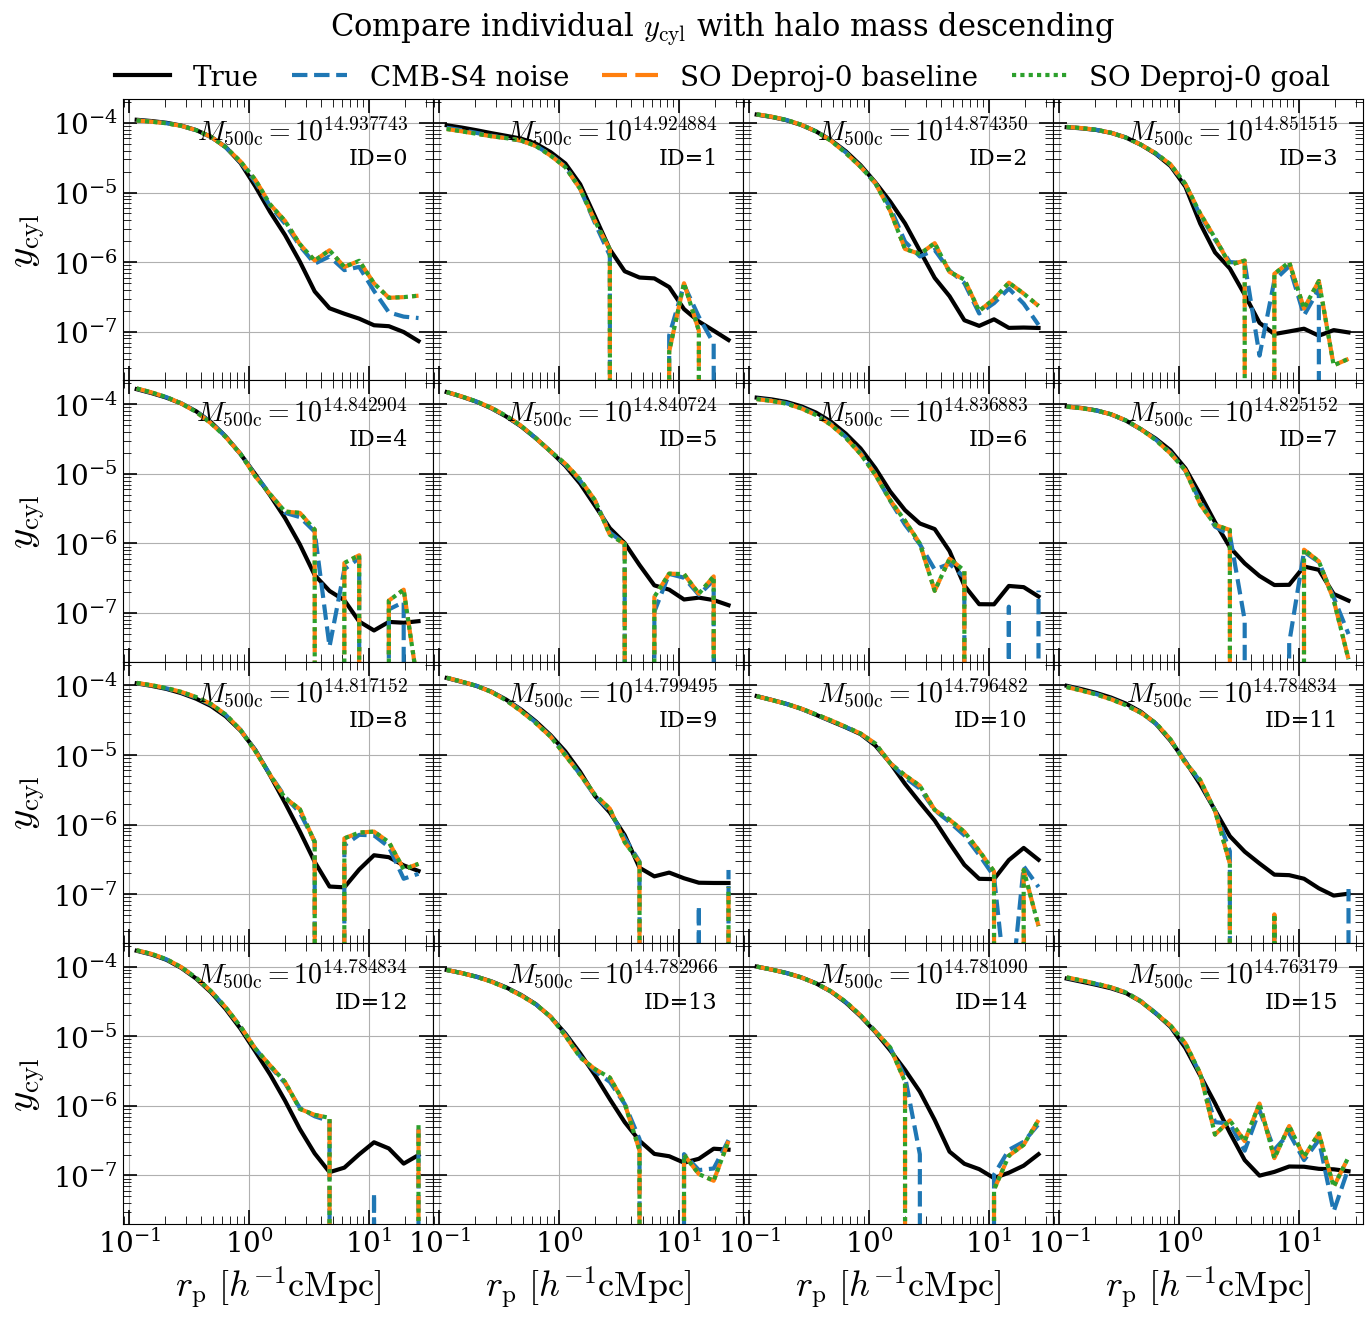

In [9]:


idx_descending = np.argsort(halo_mass_all)[::-1]

fig, axes = plt.subplots(
    4, 4, figsize=(16, 15),
    sharex=True, sharey=True
)
axes = axes.ravel()

for ii in range(16):
    ax = axes[ii]
    idx = idx_descending[ii]

    ax.plot(rp_ih_all[idx, :], cy_ih_all[idx, :],
            '-', lw=3, alpha=1, color='black',
            label="True")

    ax.plot(rp_ih_all[idx, :], cy_ih_s4noise[idx, :],
            '--', lw=3, alpha=1,
            label="CMB-S4 noise")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_glnoise_dp0[idx, :],
            '--', dashes=(6,2), lw=3, alpha=1,
            label="SO Deproj-0 baseline")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_glnoise_dp0[idx, :],
            '-', dashes=(1,1), lw=3, alpha=1,
            label="SO Deproj-0 goal")

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.text(
        0.92, 0.95,
        rf"$M_{{\rm 500c}} = 10^{{{np.log10(halo_mass_all[idx]):.6f}}}$",
        transform=ax.transAxes, ha='right', va='top', fontsize=20
    )
    ax.text(
        0.92, 0.83,
        f"ID={ii}",
        transform=ax.transAxes, ha='right', va='top', fontsize=16
    )

    ax.tick_params(axis='both', which='both', labelsize=20, length=6, width=0.6,
                   top=True, right=True, direction='in')
    ax.tick_params(axis='both', which='major', length=10, width=1.2,
                   top=True, right=True, direction='in')
    ax.minorticks_on()
    ax.grid(True)

# tighten spacing between panels + leave room on top for title+legend
fig.subplots_adjust(wspace=0, hspace=0, top=0.86)

for ax in axes[12:]:
    ax.set_xlabel(r'$r_{\rm p}\ [\it h^{-1}\rm cMpc]$', fontsize=26)
for ax in axes[0::4]:
    ax.set_ylabel(r'$y_{\mathrm{cyl}}$', fontsize=28)

# apply ylim to ALL panels 
ylim = (2e-8, 2.2e-4)
for ax in axes:
    ax.set_ylim(*ylim)

# global title
fig.suptitle(r"Compare individual $y_{\rm cyl}$ with halo mass descending",
             fontsize=22, y=0.92)

# ---- figure legend: top of figure, but below suptitle ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.90),   
           ncol=4,
           frameon=False,
           fontsize=20,
           handlelength=2.0,
           columnspacing=1.2)

plt.show()



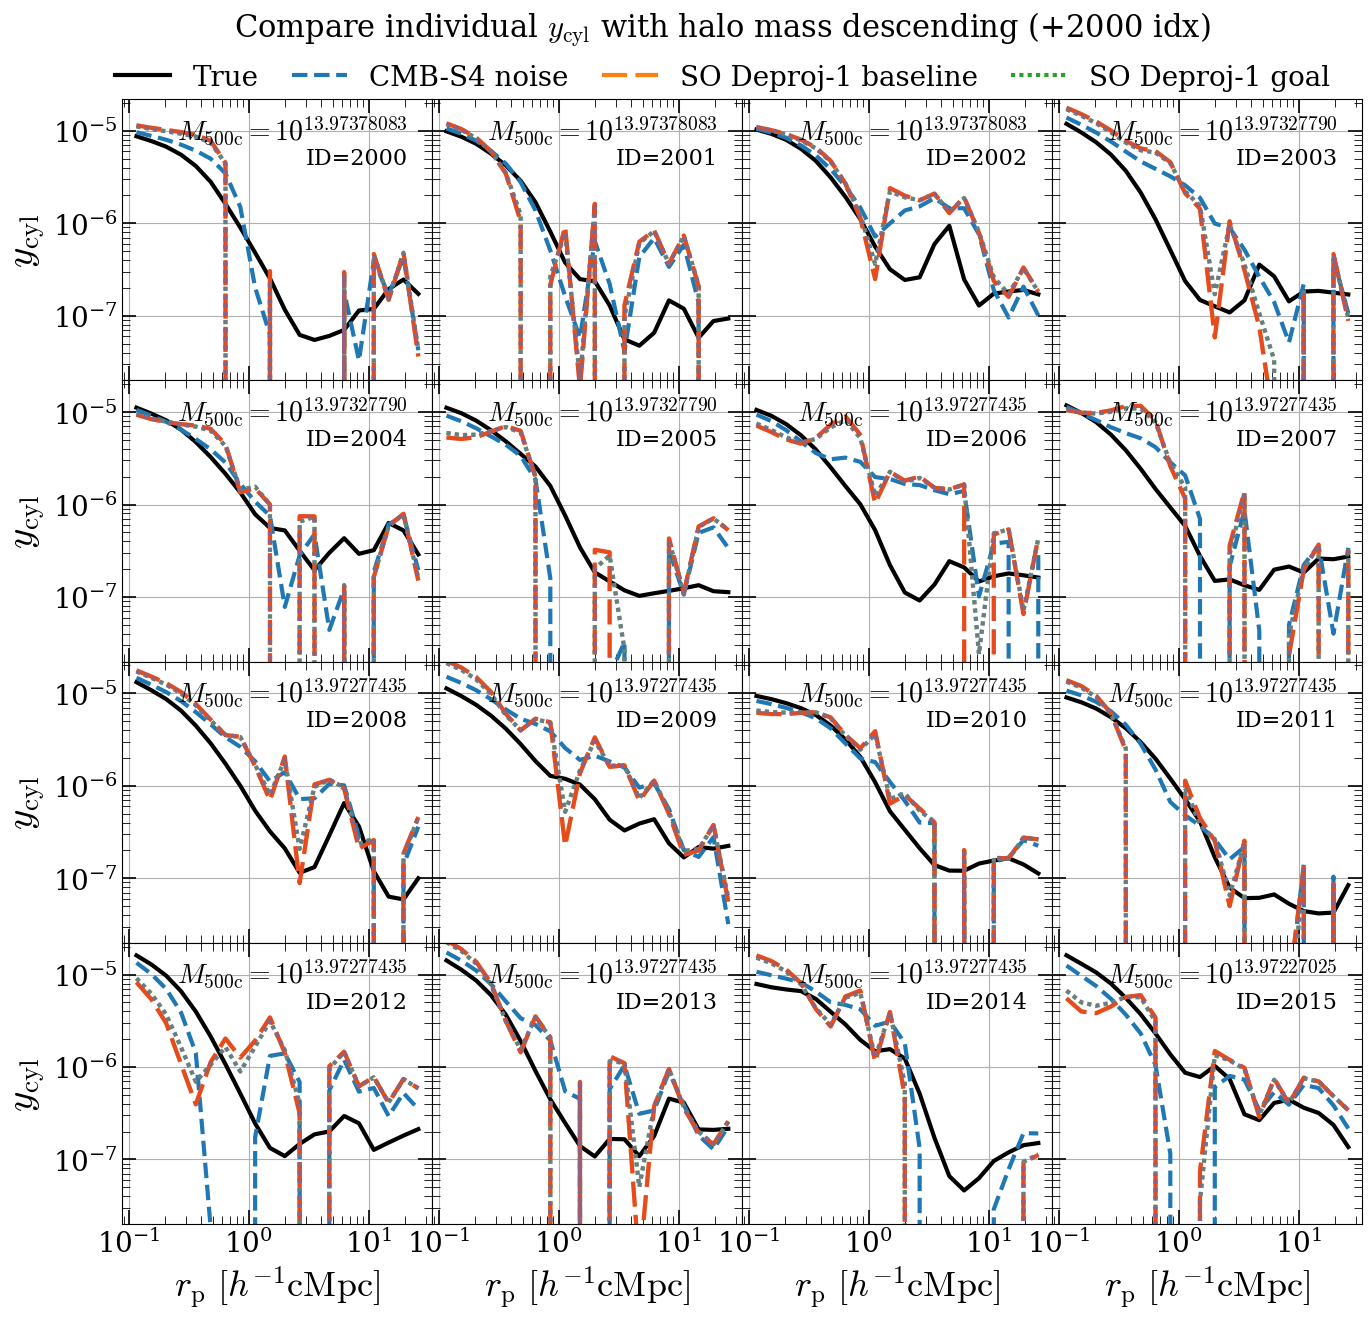

In [10]:
# idx_descending = np.argsort(halo_mass_all)[::-1]

fig, axes = plt.subplots(
    4, 4, figsize=(16, 15),
    sharex=True, sharey=True
)
axes = axes.ravel()

for ii in range(16):
    ax = axes[ii]
    idx = idx_descending[ii+2000]

    ax.plot(rp_ih_all[idx, :], cy_ih_all[idx, :],
            '-', lw=3, alpha=1, color='black',
            label="True")

    ax.plot(rp_ih_all[idx, :], cy_ih_s4noise[idx, :],
            '--', lw=3, alpha=1,
            label="CMB-S4 noise")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_blnoise_dp1[idx, :],
            '--', dashes=(6,2), lw=3, alpha=1,
            label="SO Deproj-1 baseline")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_glnoise_dp1[idx, :],
            '-', dashes=(1,1), lw=3, alpha=1,
            label="SO Deproj-1 goal")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_blnoise_dp1[idx, :],
            '--', dashes=(6,2), lw=3, alpha=0.6)#,
            # label="SO Deproj-1 baseline")

    ax.plot(rp_ih_all[idx, :], cy_ih_so_glnoise_dp1[idx, :],
            '-', dashes=(1,1), lw=3, alpha=0.6)#,
            # label="SO Deproj-1 goal")

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.text(
        0.92, 0.95,
        rf"$M_{{\rm 500c}} = 10^{{{np.log10(halo_mass_all[idx]):.8f}}}$",
        transform=ax.transAxes, ha='right', va='top', fontsize=20
    )
    ax.text(
        0.92, 0.83,
        f"ID={ii+2000}",
        transform=ax.transAxes, ha='right', va='top', fontsize=16
    )

    ax.tick_params(axis='both', which='both', labelsize=20, length=6, width=0.6,
                   top=True, right=True, direction='in')
    ax.tick_params(axis='both', which='major', length=10, width=1.2,
                   top=True, right=True, direction='in')
    ax.minorticks_on()
    ax.grid(True)

# tighten spacing between panels + leave room on top for title+legend
fig.subplots_adjust(wspace=0, hspace=0, top=0.86)

for ax in axes[12:]:
    ax.set_xlabel(r'$r_{\rm p}\ [\it h^{-1}\rm cMpc]$', fontsize=26)
for ax in axes[0::4]:
    ax.set_ylabel(r'$y_{\mathrm{cyl}}$', fontsize=28)

# apply ylim to ALL panels 
ylim = (2e-8, 2.2e-5)
for ax in axes:
    ax.set_ylim(*ylim)

# global title
fig.suptitle(r"Compare individual $y_{\rm cyl}$ with halo mass descending (+2000 idx)",
             fontsize=22, y=0.92)

# ---- figure legend: top of figure, but below suptitle ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.90),  
           ncol=4,
           frameon=False,
           fontsize=20,
           handlelength=2.0,
           columnspacing=1.2)

plt.show()
